# Exploration exhaustive — chaque colonne du dataset representee

Ce notebook remplace l'approche precedente (rapport texte qui tronquait silencieusement
les categories les plus rares). Regle appliquee ici : **chaque colonne du dataset source
est representee, meme si son taux d'exploitation est minime** (ex. `Root cause`
rempli a 0,02%, soit 4 tickets sur 18 094) — via un graphique quand il a une valeur
analytique, sinon via un resume statistique (remplissage, cardinalite, et pour le
numerique moyenne/mediane/quartiles/outliers).

Pas de graphique pour les identifiants (numero de telephone, de compte, de carte...) :
leur magnitude numerique n'a pas de sens statistique, un histogramme dessus serait
trompeur — seules les vraies mesures (montants, scores...) sont chartees, en boite a
moustaches (lisible malgre les valeurs aberrantes extremes, avec les outliers IQR
individuellement traces). Pas de pie chart (les petites parts y deviennent illisibles),
pas de "top N", pas de regroupement automatique dans un bucket "Autres" : voir
`viz_utils.py` pour le detail de la logique de selection par colonne.

**Source :** `SRC_Intercom_Reclamation_202607201846.csv` (18 094 lignes, 67 colonnes)

In [8]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, ".")
sys.path.insert(0, "..")

from viz_utils import display_profile, print_full_value_counts

PROJECT_DIR = Path("..").resolve()
RAW_CSV = PROJECT_DIR / "SRC_Intercom_Reclamation_202607201846.csv"
PHASE3_CSV = PROJECT_DIR / "reclamations_phase3.csv"

plt.rcParams["figure.dpi"] = 100

df = pd.read_csv(RAW_CSV, low_memory=False)
print(f"{len(df)} lignes, {df.shape[1]} colonnes")

18094 lignes, 67 colonnes


## 0. Vue d'ensemble — taux de remplissage et cardinalite de TOUTES les colonnes

Table de reference (aucune colonne omise) avant de detailler chacune en graphique.

In [10]:
profil = pd.DataFrame({
    "remplissage_pct": (df.notna().mean() * 100).round(2),
    "nb_remplis": df.notna().sum(),
    "nb_valeurs_uniques": df.nunique(dropna=True),
    "dtype": df.dtypes.astype(str),
}).sort_values("remplissage_pct", ascending=False)

print(f"{len(profil)} colonnes au total (=100% des colonnes du dataset)")
with pd.option_context("display.max_rows", None, "display.width", 120):
    print(profil)

67 colonnes au total (=100% des colonnes du dataset)
                                                   remplissage_pct  nb_remplis  nb_valeurs_uniques    dtype
type                                                        100.00       18094                   1   object
id                                                          100.00       18094               18094    int64
ticket_id                                                   100.00       18094               18094    int64
ticket_state_internal_label                                 100.00       18094                   4   object
ticket_type_id                                              100.00       18094                  17    int64
ticket_state_external_label                                 100.00       18094                   4   object
ticket_type_type                                            100.00       18094                   1   object
ticket_state_id                                             100.00       18094     

## 1. Identifiants & etat du ticket

--- type ---
    dtype: object
    remplissage_pct: 100.0
    nb_remplis: 18094
    nb_valeurs_uniques: 1
    valeur_plus_frequente: ticket
    pct_valeur_plus_frequente: 100.0
    (pas de graphique - identifiant/texte libre/JSON/colonne constante : sans valeur analytique pour un graphique)
--- id ---
    dtype: int64
    remplissage_pct: 100.0
    nb_remplis: 18094
    nb_valeurs_uniques: 18094
    valeur_plus_frequente: 44
    pct_valeur_plus_frequente: 0.01
    (pas de graphique - identifiant/texte libre/JSON/colonne constante : sans valeur analytique pour un graphique)
--- ticket_id ---
    dtype: int64
    remplissage_pct: 100.0
    nb_remplis: 18094
    nb_valeurs_uniques: 18094
    valeur_plus_frequente: 5
    pct_valeur_plus_frequente: 0.01
    (pas de graphique - identifiant/texte libre/JSON/colonne constante : sans valeur analytique pour un graphique)
--- ticket_state_type ---
    dtype: object
    remplissage_pct: 100.0
    nb_remplis: 18094
    nb_valeurs_uniques: 1
    val

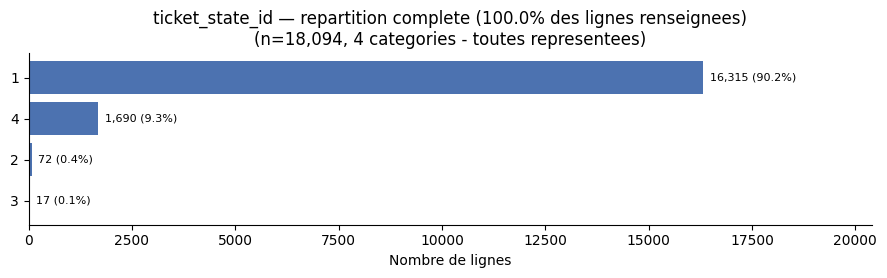

--- ticket_state_category ---
    dtype: object
    remplissage_pct: 100.0
    nb_remplis: 18094
    nb_valeurs_uniques: 4
    valeur_plus_frequente: submitted
    pct_valeur_plus_frequente: 90.17


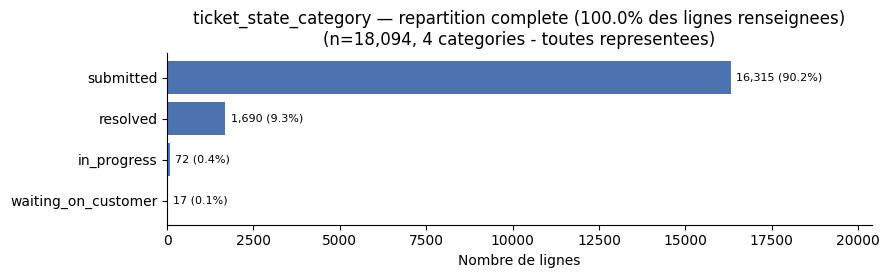

--- ticket_state_internal_label ---
    dtype: object
    remplissage_pct: 100.0
    nb_remplis: 18094
    nb_valeurs_uniques: 4
    valeur_plus_frequente: Submitted
    pct_valeur_plus_frequente: 90.17


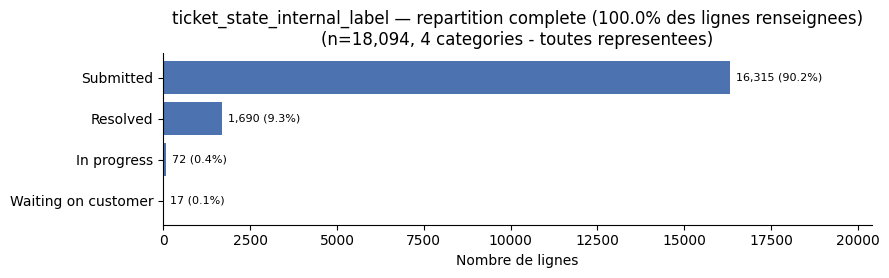

--- ticket_state_external_label ---
    dtype: object
    remplissage_pct: 100.0
    nb_remplis: 18094
    nb_valeurs_uniques: 4
    valeur_plus_frequente: Submitted
    pct_valeur_plus_frequente: 90.17


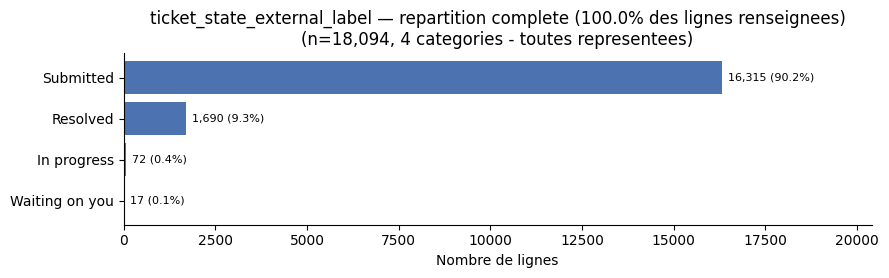

--- open ---
    dtype: bool
    remplissage_pct: 100.0
    nb_remplis: 18094
    nb_valeurs_uniques: 2
    valeur_plus_frequente: False
    pct_valeur_plus_frequente: 99.73


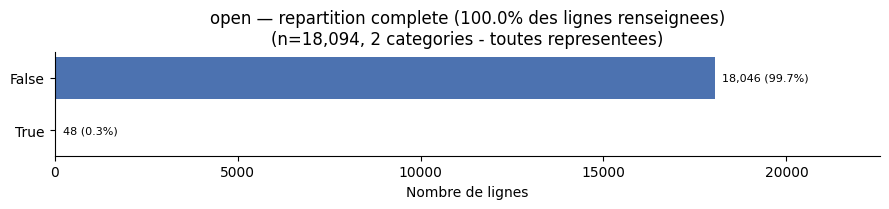

--- category ---
    dtype: object
    remplissage_pct: 100.0
    nb_remplis: 18094
    nb_valeurs_uniques: 3
    valeur_plus_frequente: Customer
    pct_valeur_plus_frequente: 99.93


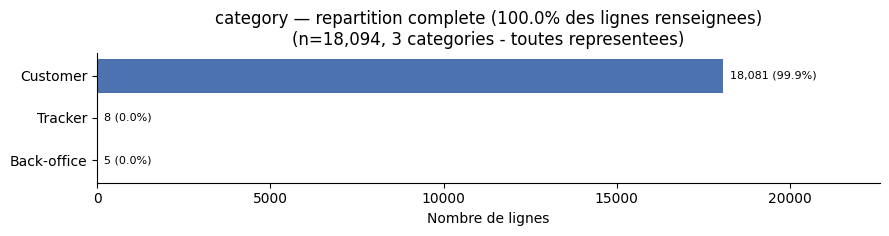

--- ticket_type_category ---
    dtype: object
    remplissage_pct: 100.0
    nb_remplis: 18094
    nb_valeurs_uniques: 3
    valeur_plus_frequente: Customer
    pct_valeur_plus_frequente: 99.93


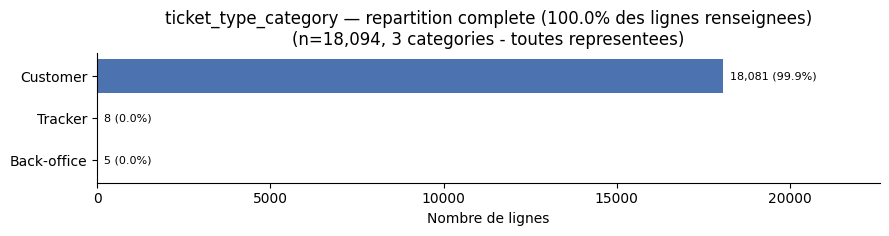

In [12]:
cols = ["type", "id", "ticket_id", "ticket_state_type", "ticket_state_id", "ticket_state_category", "ticket_state_internal_label", "ticket_state_external_label", "open", "category", "ticket_type_category"]
for c in cols:
    display_profile(df, c)


## 2. Classification — type de reclamation (`ticket_type_*`)

--- ticket_type_type ---
    dtype: object
    remplissage_pct: 100.0
    nb_remplis: 18094
    nb_valeurs_uniques: 1
    valeur_plus_frequente: ticket_type
    pct_valeur_plus_frequente: 100.0
    (pas de graphique - identifiant/texte libre/JSON/colonne constante : sans valeur analytique pour un graphique)
--- ticket_type_id ---
    dtype: int64
    remplissage_pct: 100.0
    nb_remplis: 18094
    nb_valeurs_uniques: 17
    valeur_plus_frequente: 2954451
    pct_valeur_plus_frequente: 59.03


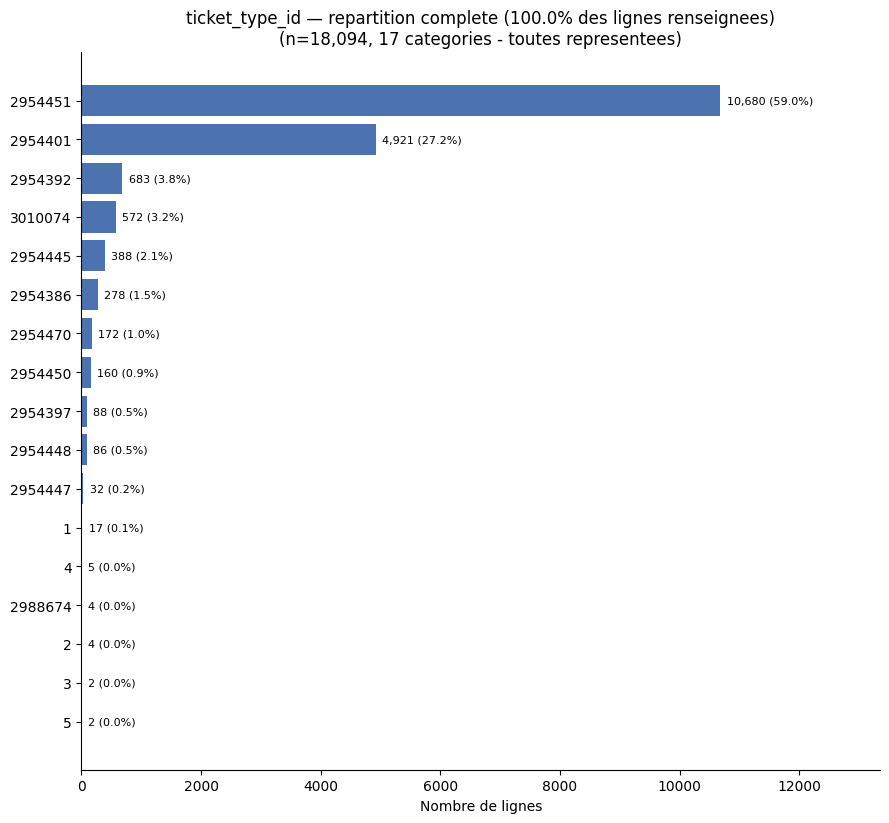

--- ticket_type_name ---
    dtype: object
    remplissage_pct: 100.0
    nb_remplis: 18094
    nb_valeurs_uniques: 17
    valeur_plus_frequente: SARA
    pct_valeur_plus_frequente: 59.03


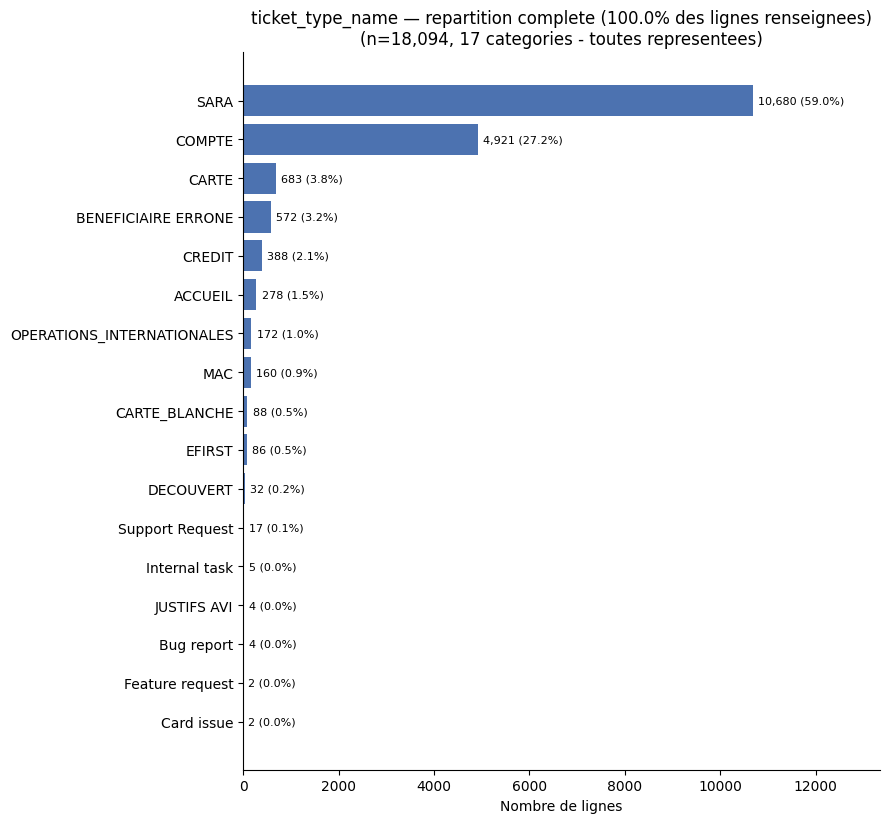

/home/gauss/Bureau/Afriland/sentiment analysis/notebooks/./viz_utils.py:95: UserWarning: Glyph 26 () missing from font(s) DejaVu Sans.
  fig.tight_layout()
/home/gauss/Bureau/Afriland/sentiment analysis/notebooks/./viz_utils.py:95: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()
/usr/lib/python3/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26 () missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


--- ticket_type_description ---
    dtype: object
    remplissage_pct: 0.15
    nb_remplis: 28
    nb_valeurs_uniques: 4
    valeur_plus_frequente: When a customer query cant be instantly resolved, convert to support request ticket to ensure the right details are captured and allow customers to keep track of progress.
    pct_valeur_plus_frequente: 60.71


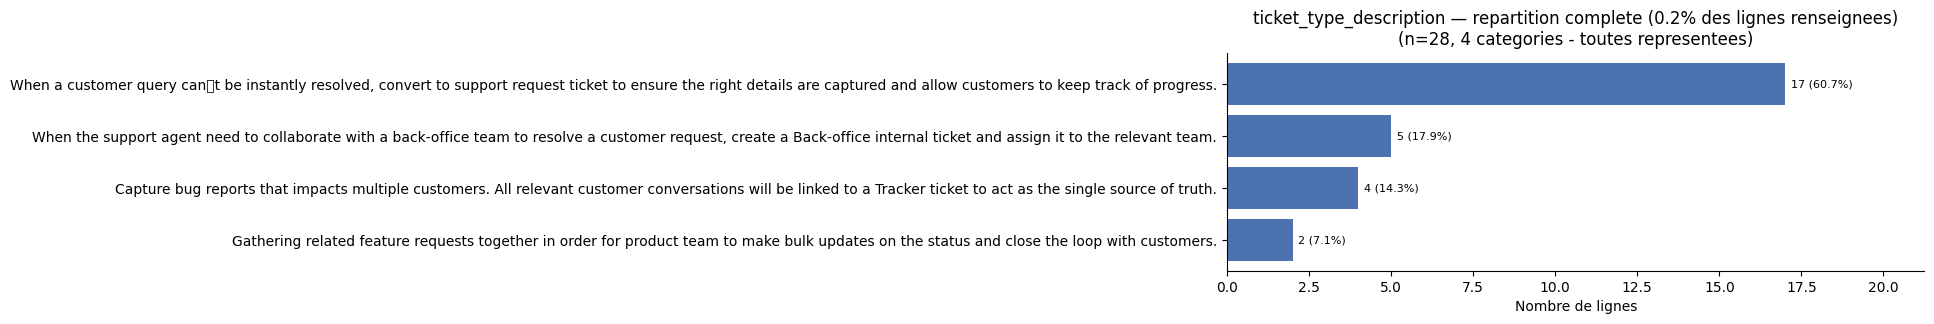

--- ticket_type_icon ---
    dtype: object
    remplissage_pct: 100.0
    nb_remplis: 18094
    nb_valeurs_uniques: 1
    valeur_plus_frequente: 
    pct_valeur_plus_frequente: 100.0
    (pas de graphique - identifiant/texte libre/JSON/colonne constante : sans valeur analytique pour un graphique)
--- ticket_type_workspace_id ---
    dtype: object
    remplissage_pct: 100.0
    nb_remplis: 18094
    nb_valeurs_uniques: 1
    valeur_plus_frequente: qc17uywk
    pct_valeur_plus_frequente: 100.0
    (pas de graphique - identifiant/texte libre/JSON/colonne constante : sans valeur analytique pour un graphique)
--- ticket_type_archived ---
    dtype: bool
    remplissage_pct: 100.0
    nb_remplis: 18094
    nb_valeurs_uniques: 1
    valeur_plus_frequente: False
    pct_valeur_plus_frequente: 100.0
    (pas de graphique - identifiant/texte libre/JSON/colonne constante : sans valeur analytique pour un graphique)
--- ticket_type_created_at ---
    dtype: object
    remplissage_pct: 100.0
    nb

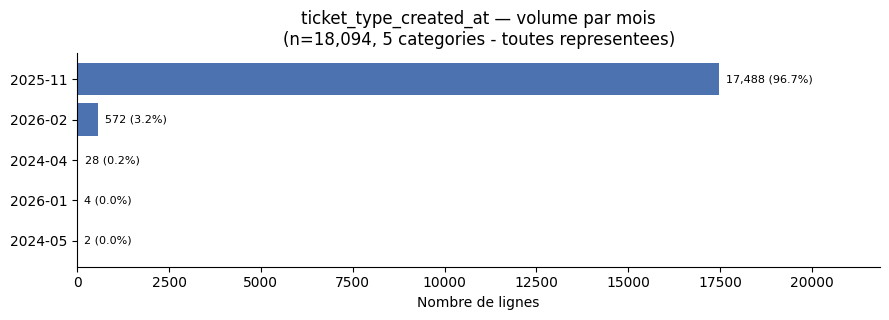

--- ticket_type_updated_at ---
    dtype: object
    remplissage_pct: 100.0
    nb_remplis: 18094
    nb_valeurs_uniques: 16
    valeur_plus_frequente: 2025-11-07 13:45:11.000
    pct_valeur_plus_frequente: 59.03


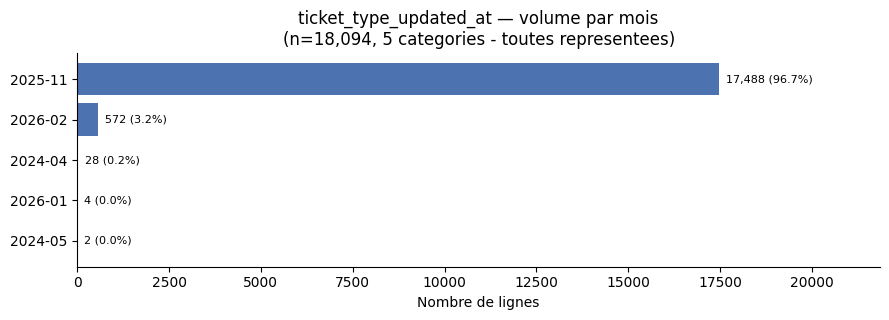

--- ticket_type_is_internal ---
    dtype: bool
    remplissage_pct: 100.0
    nb_remplis: 18094
    nb_valeurs_uniques: 2
    valeur_plus_frequente: False
    pct_valeur_plus_frequente: 99.93


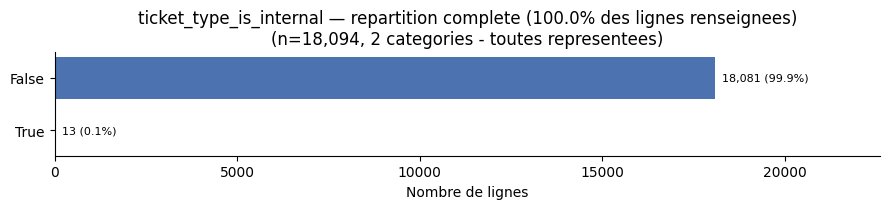

--- ticket_type_ticket_type_attributes_type ---
    dtype: object
    remplissage_pct: 100.0
    nb_remplis: 18094
    nb_valeurs_uniques: 1
    valeur_plus_frequente: list
    pct_valeur_plus_frequente: 100.0
    (pas de graphique - identifiant/texte libre/JSON/colonne constante : sans valeur analytique pour un graphique)
--- ticket_type_ticket_type_attributes_data ---
    dtype: object
    remplissage_pct: 100.0
    nb_remplis: 18094
    nb_valeurs_uniques: 1
    valeur_plus_frequente: [{"t
    pct_valeur_plus_frequente: 100.0
    (pas de graphique - identifiant/texte libre/JSON/colonne constante : sans valeur analytique pour un graphique)


In [14]:
cols = ["ticket_type_type", "ticket_type_id", "ticket_type_name", "ticket_type_description", "ticket_type_icon", "ticket_type_workspace_id", "ticket_type_archived", "ticket_type_created_at", "ticket_type_updated_at", "ticket_type_is_internal", "ticket_type_ticket_type_attributes_type", "ticket_type_ticket_type_attributes_data"]
for c in cols:
    display_profile(df, c)


## 3. Contact, canal, assignation

--- contacts_type ---
    dtype: object
    remplissage_pct: 100.0
    nb_remplis: 18094
    nb_valeurs_uniques: 1
    valeur_plus_frequente: contact.list
    pct_valeur_plus_frequente: 100.0
    (pas de graphique - identifiant/texte libre/JSON/colonne constante : sans valeur analytique pour un graphique)
--- contacts_contacts ---
    dtype: object
    remplissage_pct: 100.0
    nb_remplis: 18094
    nb_valeurs_uniques: 10955
    valeur_plus_frequente: [{"type": "contact", "id": "664f6ec021fd9a9dcb196ad2", "external_id": "670703236"}]
    pct_valeur_plus_frequente: 0.26
    (pas de graphique - identifiant/texte libre/JSON/colonne constante : sans valeur analytique pour un graphique)
--- admin_assignee_id ---
    dtype: int64
    remplissage_pct: 100.0
    nb_remplis: 18094
    nb_valeurs_uniques: 8
    valeur_plus_frequente: 8985527
    pct_valeur_plus_frequente: 28.45


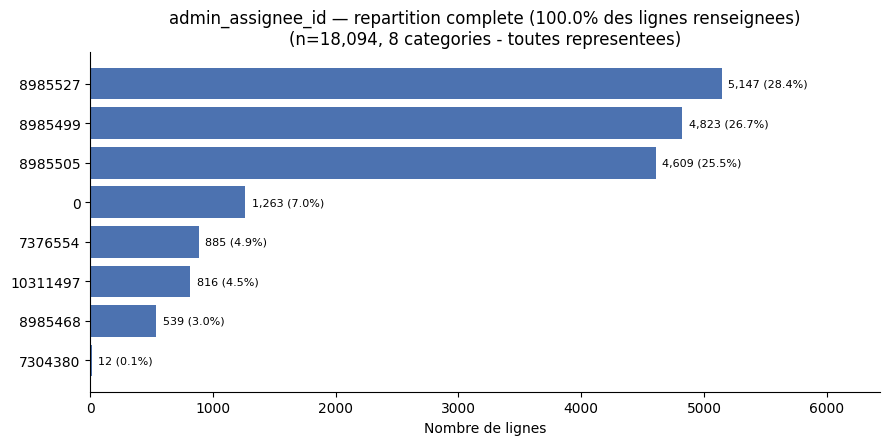

--- team_assignee_id ---
    dtype: int64
    remplissage_pct: 100.0
    nb_remplis: 18094
    nb_valeurs_uniques: 4
    valeur_plus_frequente: 7376599
    pct_valeur_plus_frequente: 60.85


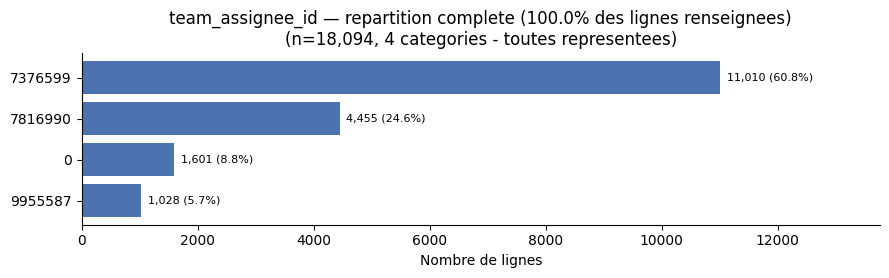

--- channel ---
    dtype: object
    remplissage_pct: 100.0
    nb_remplis: 18094
    nb_valeurs_uniques: 7
    valeur_plus_frequente: android
    pct_valeur_plus_frequente: 65.56


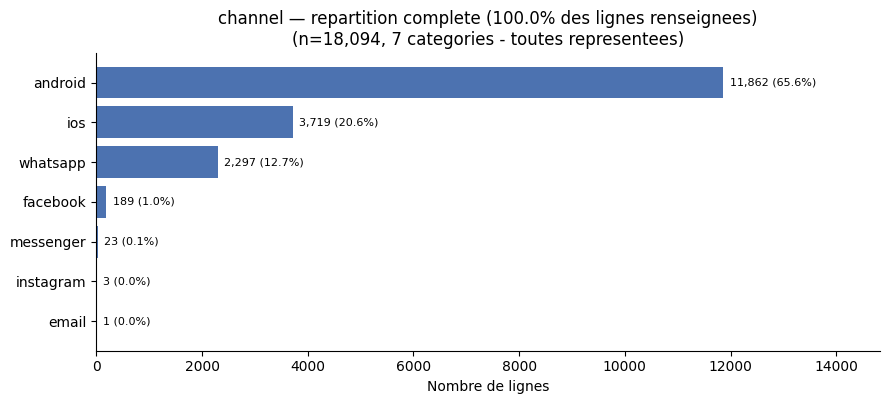

--- is_shared ---
    dtype: bool
    remplissage_pct: 100.0
    nb_remplis: 18094
    nb_valeurs_uniques: 2
    valeur_plus_frequente: True
    pct_valeur_plus_frequente: 99.93


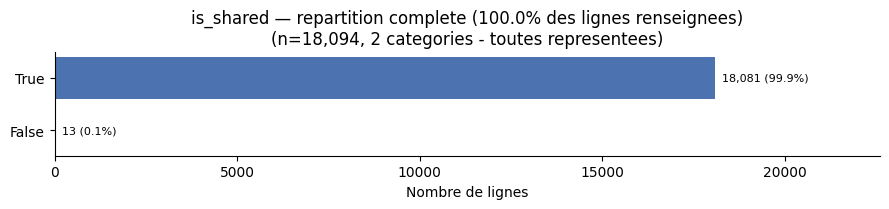

In [16]:
cols = ["contacts_type", "contacts_contacts", "admin_assignee_id", "team_assignee_id", "channel", "is_shared"]
for c in cols:
    display_profile(df, c)


## 4. Horodatage

--- created_at ---
    dtype: object
    remplissage_pct: 100.0
    nb_remplis: 18094
    nb_valeurs_uniques: 18064
    valeur_plus_frequente: 2026-03-31 08:22:32.000
    pct_valeur_plus_frequente: 0.01


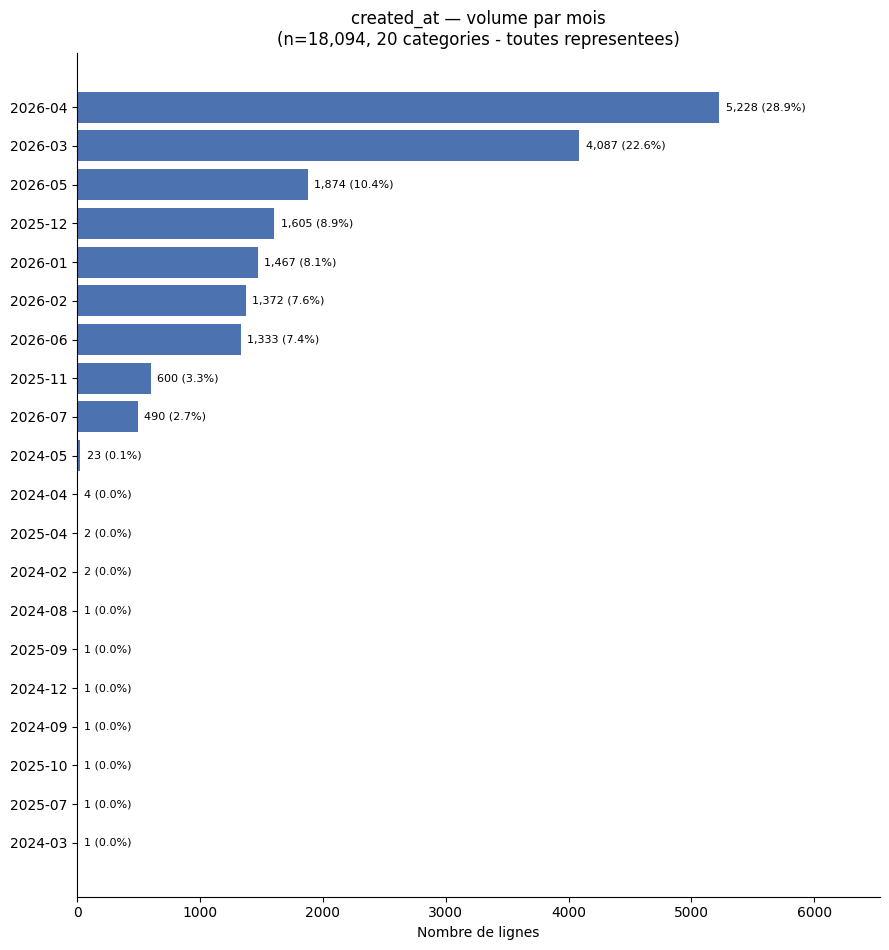

--- updated_at ---
    dtype: object
    remplissage_pct: 100.0
    nb_remplis: 18094
    nb_valeurs_uniques: 16964
    valeur_plus_frequente: 2026-03-30 08:13:53.000
    pct_valeur_plus_frequente: 0.22


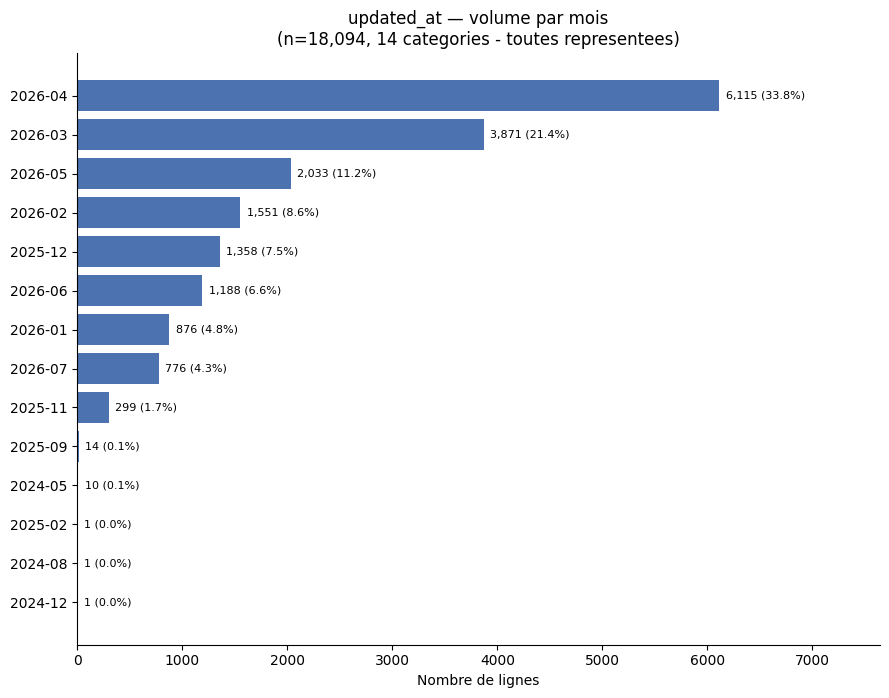

In [18]:
cols = ["created_at", "updated_at"]
for c in cols:
    display_profile(df, c)


## 5. Parties du ticket / objets lies (metadonnees techniques Intercom)

--- ticket_parts_type ---
    dtype: object
    remplissage_pct: 100.0
    nb_remplis: 18094
    nb_valeurs_uniques: 1
    valeur_plus_frequente: ticket_part.list
    pct_valeur_plus_frequente: 100.0
    (pas de graphique - identifiant/texte libre/JSON/colonne constante : sans valeur analytique pour un graphique)
--- ticket_parts_ticket_parts ---
    dtype: object
    remplissage_pct: 100.0
    nb_remplis: 18094
    nb_valeurs_uniques: 1
    valeur_plus_frequente: [{"t
    pct_valeur_plus_frequente: 100.0
    (pas de graphique - identifiant/texte libre/JSON/colonne constante : sans valeur analytique pour un graphique)
--- ticket_parts_total_count ---
    dtype: float64
    remplissage_pct: 100.0
    nb_remplis: 18094
    nb_valeurs_uniques: 103
    moyenne: 27.76
    mediane: 26.0
    ecart_type: 8.0
    min: 5.0
    q1: 23.0
    q3: 31.0
    max: 171.0
    nb_outliers_iqr: 664
    pct_outliers: 3.67


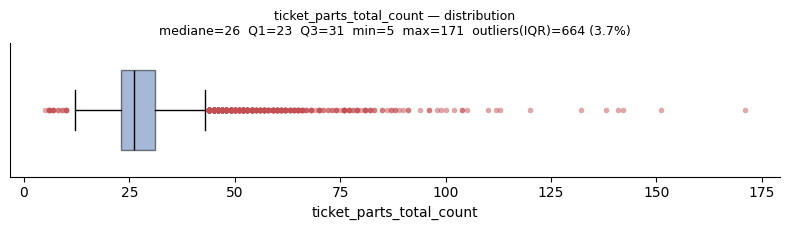

--- linked_objects_type ---
    dtype: object
    remplissage_pct: 100.0
    nb_remplis: 18094
    nb_valeurs_uniques: 1
    valeur_plus_frequente: list
    pct_valeur_plus_frequente: 100.0
    (pas de graphique - identifiant/texte libre/JSON/colonne constante : sans valeur analytique pour un graphique)
--- linked_objects_data ---
    dtype: object
    remplissage_pct: 100.0
    nb_remplis: 18094
    nb_valeurs_uniques: 18
    valeur_plus_frequente: []
    pct_valeur_plus_frequente: 99.91


/home/gauss/Bureau/Afriland/sentiment analysis/notebooks/./viz_utils.py:95: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


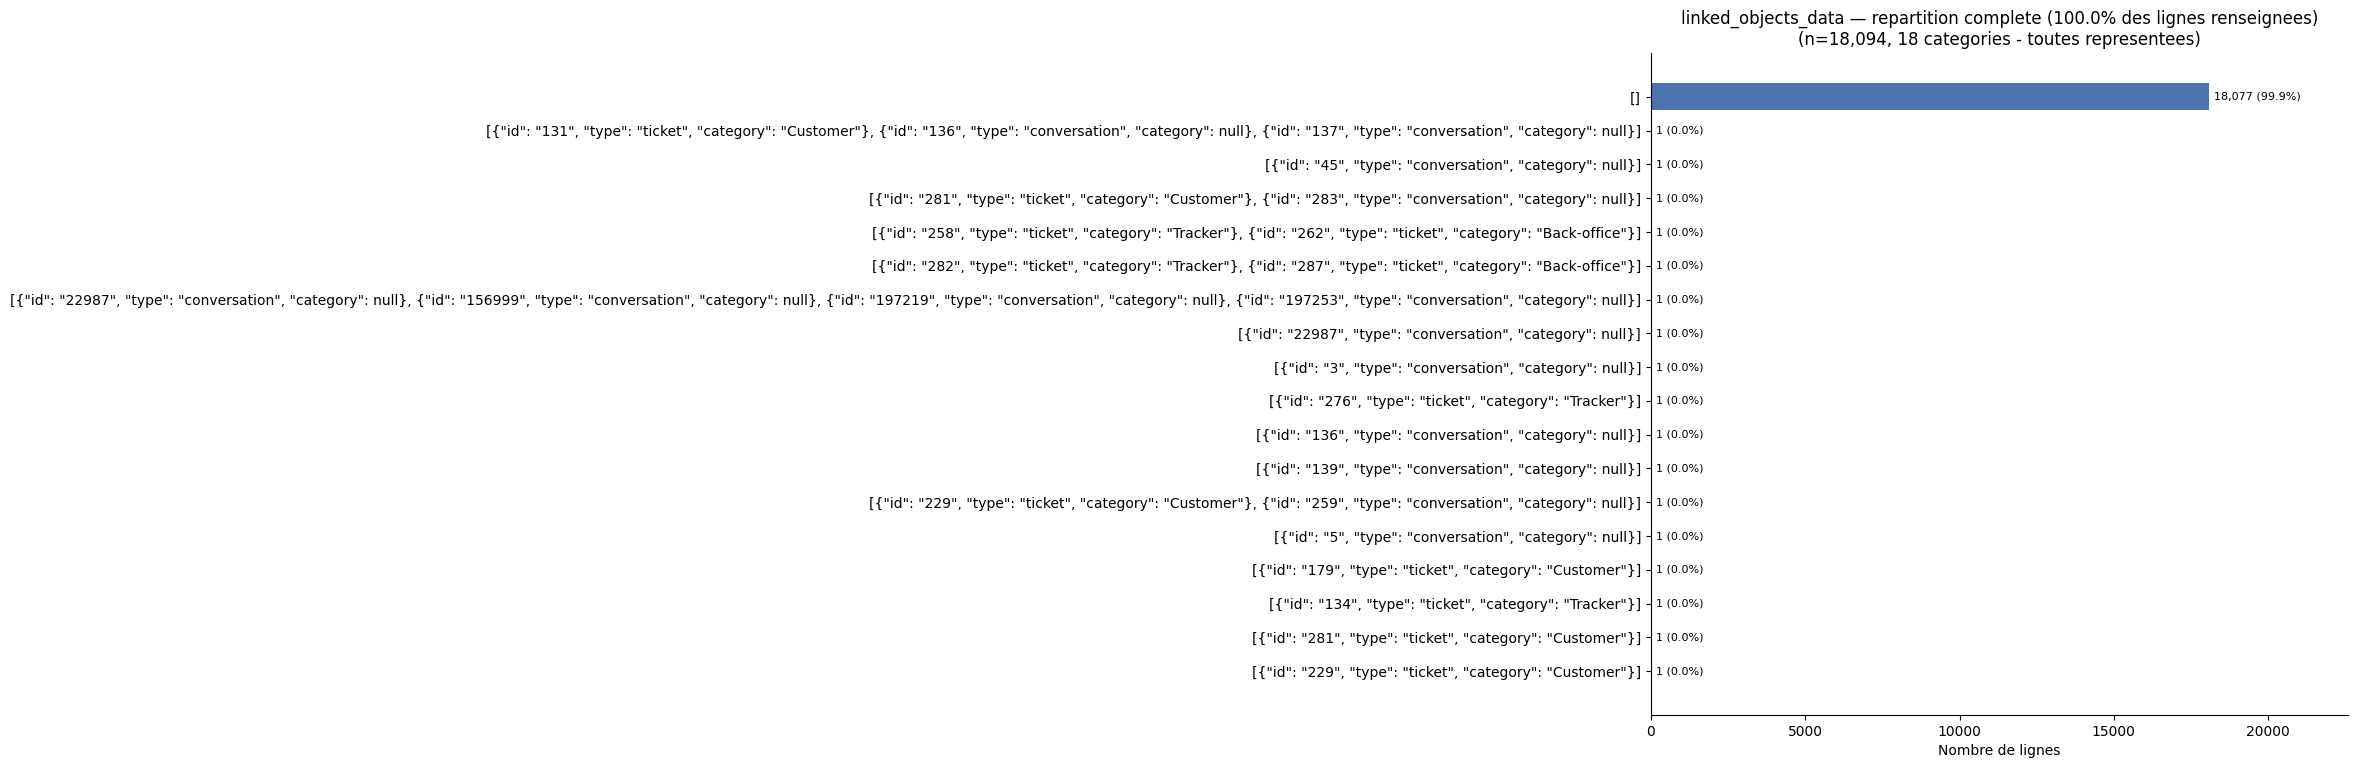

--- linked_objects_total_count ---
    dtype: float64
    remplissage_pct: 100.0
    nb_remplis: 18094
    nb_valeurs_uniques: 5
    moyenne: 0.0
    mediane: 0.0
    ecart_type: 0.05
    min: 0.0
    q1: 0.0
    q3: 0.0
    max: 4.0
    nb_outliers_iqr: 17
    pct_outliers: 0.09


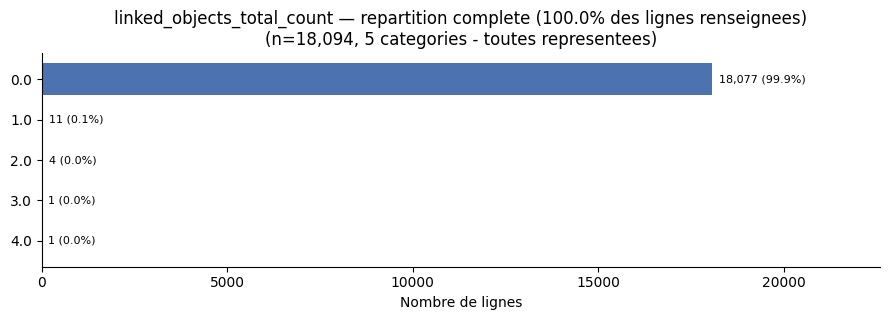

--- linked_objects_has_more ---
    dtype: bool
    remplissage_pct: 100.0
    nb_remplis: 18094
    nb_valeurs_uniques: 1
    valeur_plus_frequente: False
    pct_valeur_plus_frequente: 100.0
    (pas de graphique - identifiant/texte libre/JSON/colonne constante : sans valeur analytique pour un graphique)


In [20]:
cols = ["ticket_parts_type", "ticket_parts_ticket_parts", "ticket_parts_total_count", "linked_objects_type", "linked_objects_data", "linked_objects_total_count", "linked_objects_has_more"]
for c in cols:
    display_profile(df, c)


## 6. Attributs metier frequents (29% a 46% de remplissage)

--- ticket_attributes__default_title_ ---
    dtype: object
    remplissage_pct: 29.66
    nb_remplis: 5366
    nb_valeurs_uniques: 3326
    valeur_plus_frequente: réclamation 
    pct_valeur_plus_frequente: 9.22
    (pas de graphique - identifiant/texte libre/JSON/colonne constante : sans valeur analytique pour un graphique)
--- ticket_attributes__default_description_ ---
    dtype: object
    remplissage_pct: 45.66
    nb_remplis: 8262
    nb_valeurs_uniques: 7988
    valeur_plus_frequente: réclamation 
    pct_valeur_plus_frequente: 0.35
    (pas de graphique - identifiant/texte libre/JSON/colonne constante : sans valeur analytique pour un graphique)
--- ticket_attributes_Nom du client ---
    dtype: object
    remplissage_pct: 42.67
    nb_remplis: 7720
    nb_valeurs_uniques: 6125
    valeur_plus_frequente: OUMAROU CHRISTIAN MAXIME STEVE 
    pct_valeur_plus_frequente: 0.44
    (pas de graphique - identifiant/texte libre/JSON/colonne constante : sans valeur analytique pour un grap

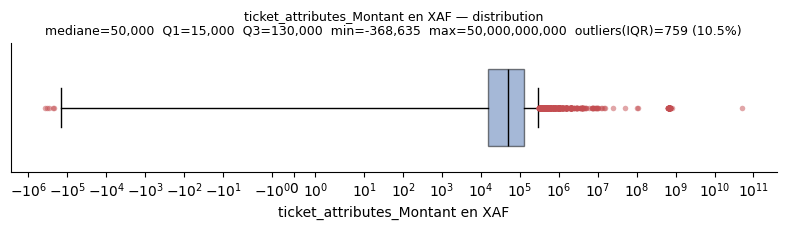

--- ticket_attributes_Reference de la transaction ---
    dtype: object
    remplissage_pct: 21.49
    nb_remplis: 3888
    nb_valeurs_uniques: 3295
    valeur_plus_frequente: 1
    pct_valeur_plus_frequente: 1.13
    (pas de graphique - identifiant/texte libre/JSON/colonne constante : sans valeur analytique pour un graphique)
--- ticket_attributes_Agence ---
    dtype: object
    remplissage_pct: 42.12
    nb_remplis: 7621
    nb_valeurs_uniques: 112
    valeur_plus_frequente: FIRST_BANK_HIPPODROME
    pct_valeur_plus_frequente: 9.4


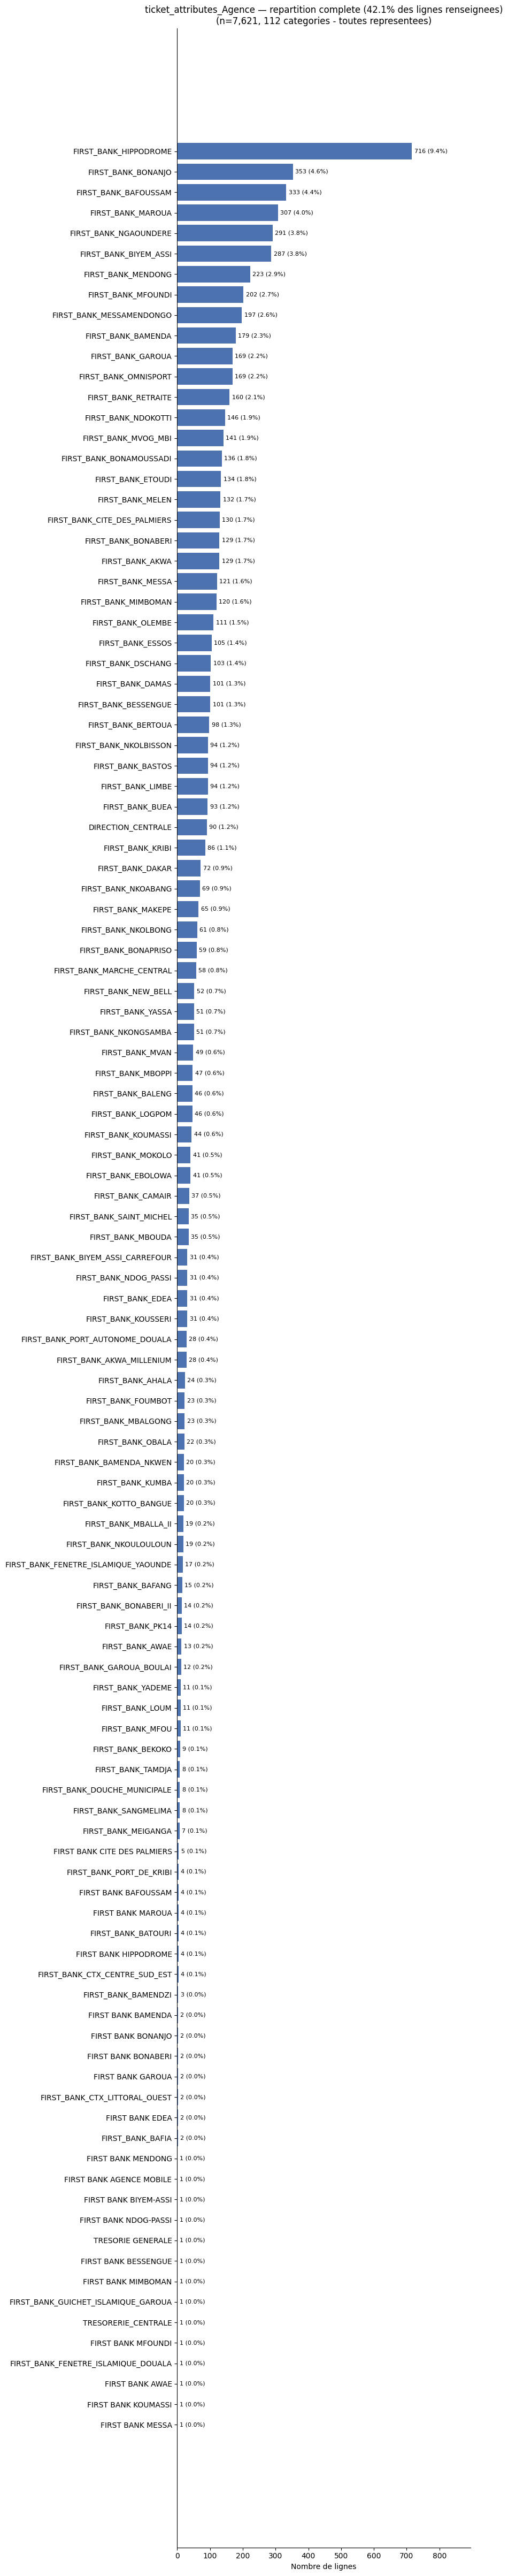

--- ticket_attributes_Date de la transaction ---
    dtype: object
    remplissage_pct: 42.27
    nb_remplis: 7648
    nb_valeurs_uniques: 2713
    valeur_plus_frequente: 20/12/2025
    pct_valeur_plus_frequente: 4.88
    (pas de graphique - identifiant/texte libre/JSON/colonne constante : sans valeur analytique pour un graphique)
--- ticket_attributes_Numero de compte ---
    dtype: object
    remplissage_pct: 28.24
    nb_remplis: 5109
    nb_valeurs_uniques: 3960
    valeur_plus_frequente: 055291282
    pct_valeur_plus_frequente: 0.92
    (pas de graphique - identifiant/texte libre/JSON/colonne constante : sans valeur analytique pour un graphique)


In [22]:
cols = ["ticket_attributes__default_title_", "ticket_attributes__default_description_", "ticket_attributes_Nom du client", "ticket_attributes_Numero_tel_client", "ticket_attributes_Montant en XAF", "ticket_attributes_Reference de la transaction", "ticket_attributes_Agence", "ticket_attributes_Date de la transaction", "ticket_attributes_Numero de compte"]
for c in cols:
    display_profile(df, c)


## 7. Attributs metier rares — de 3,2% a 0,01% de remplissage

**C'est le cas d'usage central de ce notebook** : ces colonnes sont quasiment vides (`ticket_attributes_Order number` : 1 seule ligne remplie sur 18 094, soit 0,01%) mais restent representees, exactement comme demande — rien n'est omis sous pretexte d'un faible volume.

--- ticket_attributes_Montant ---
    dtype: float64
    remplissage_pct: 3.16
    nb_remplis: 572
    nb_valeurs_uniques: 217
    moyenne: 15664369.05
    mediane: 30000.0
    ecart_type: 102202393.8
    min: 0.0
    q1: 10175.0
    q3: 100000.0
    max: 699017590.0
    nb_outliers_iqr: 56
    pct_outliers: 9.79


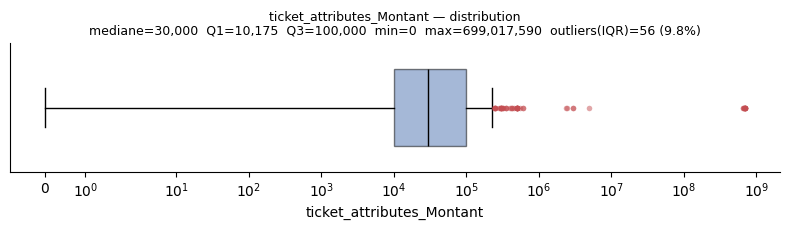

--- ticket_attributes_Numero errone ---
    dtype: float64
    remplissage_pct: 3.16
    nb_remplis: 572
    nb_valeurs_uniques: 461
    valeur_plus_frequente: 676110875.0
    pct_valeur_plus_frequente: 1.57
    (pas de graphique - identifiant/texte libre/JSON/colonne constante : sans valeur analytique pour un graphique)
--- ticket_attributes_Votre Numero ---
    dtype: float64
    remplissage_pct: 3.09
    nb_remplis: 559
    nb_valeurs_uniques: 446
    valeur_plus_frequente: 675110875.0
    pct_valeur_plus_frequente: 1.61
    (pas de graphique - identifiant/texte libre/JSON/colonne constante : sans valeur analytique pour un graphique)
--- ticket_attributes_Date de depot ---
    dtype: object
    remplissage_pct: 0.48
    nb_remplis: 87
    nb_valeurs_uniques: 75
    valeur_plus_frequente: 26/05/2026
    pct_valeur_plus_frequente: 5.75


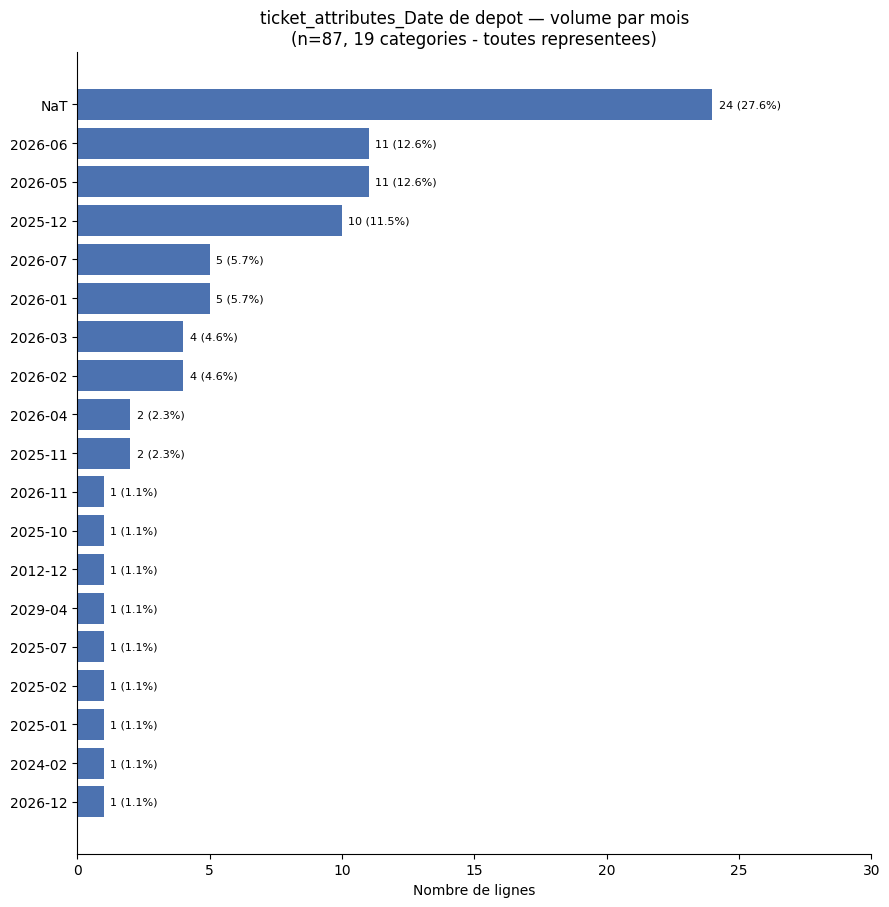

--- ticket_attributes_Agence concernee ---
    dtype: object
    remplissage_pct: 0.43
    nb_remplis: 77
    nb_valeurs_uniques: 41
    valeur_plus_frequente: FIRST_BANK_MENDONG
    pct_valeur_plus_frequente: 9.09
    (pas de graphique - identifiant/texte libre/JSON/colonne constante : sans valeur analytique pour un graphique)
--- ticket_attributes_4 derniers chiffres de la carte ---
    dtype: float64
    remplissage_pct: 0.63
    nb_remplis: 114
    nb_valeurs_uniques: 101
    valeur_plus_frequente: 9951.0
    pct_valeur_plus_frequente: 2.63
    (pas de graphique - identifiant/texte libre/JSON/colonne constante : sans valeur analytique pour un graphique)
--- ticket_attributes_Reference de la transaction1 ---
    dtype: object
    remplissage_pct: 0.03
    nb_remplis: 5
    nb_valeurs_uniques: 5
    valeur_plus_frequente: 260625 49394/260625 49395
    pct_valeur_plus_frequente: 20.0
    (pas de graphique - identifiant/texte libre/JSON/colonne constante : sans valeur analytique pour u

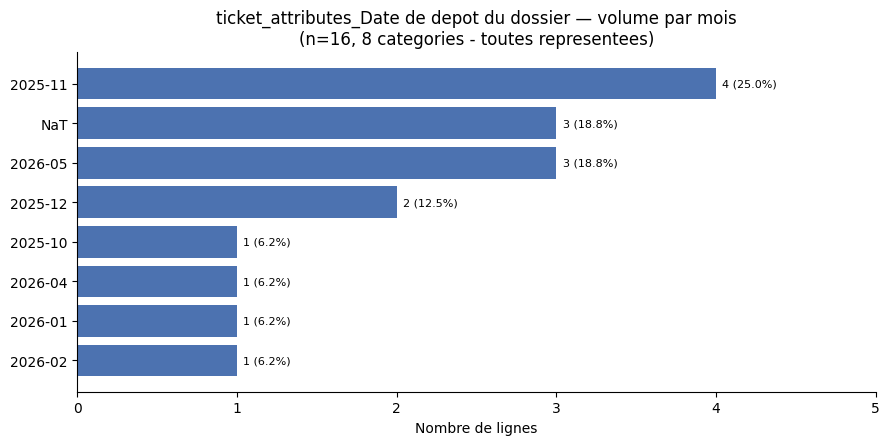

--- ticket_attributes_Platforms ---
    dtype: object
    remplissage_pct: 0.03
    nb_remplis: 6
    nb_valeurs_uniques: 4
    valeur_plus_frequente: SARA
    pct_valeur_plus_frequente: 50.0
    (pas de graphique - identifiant/texte libre/JSON/colonne constante : sans valeur analytique pour un graphique)
--- ticket_attributes_Root cause ---
    dtype: object
    remplissage_pct: 0.02
    nb_remplis: 4
    nb_valeurs_uniques: 4
    valeur_plus_frequente: Le contr)ole de numerotation sur le partenaire orange, ne prends pas en compte les numero 68
    pct_valeur_plus_frequente: 25.0
    (pas de graphique - identifiant/texte libre/JSON/colonne constante : sans valeur analytique pour un graphique)
--- ticket_attributes_Nom ---
    dtype: object
    remplissage_pct: 0.02
    nb_remplis: 4
    nb_valeurs_uniques: 4
    valeur_plus_frequente: Le client Test
    pct_valeur_plus_frequente: 25.0
    (pas de graphique - identifiant/texte libre/JSON/colonne constante : sans valeur analytique pour 

/home/gauss/Bureau/Afriland/sentiment analysis/notebooks/./viz_utils.py:95: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


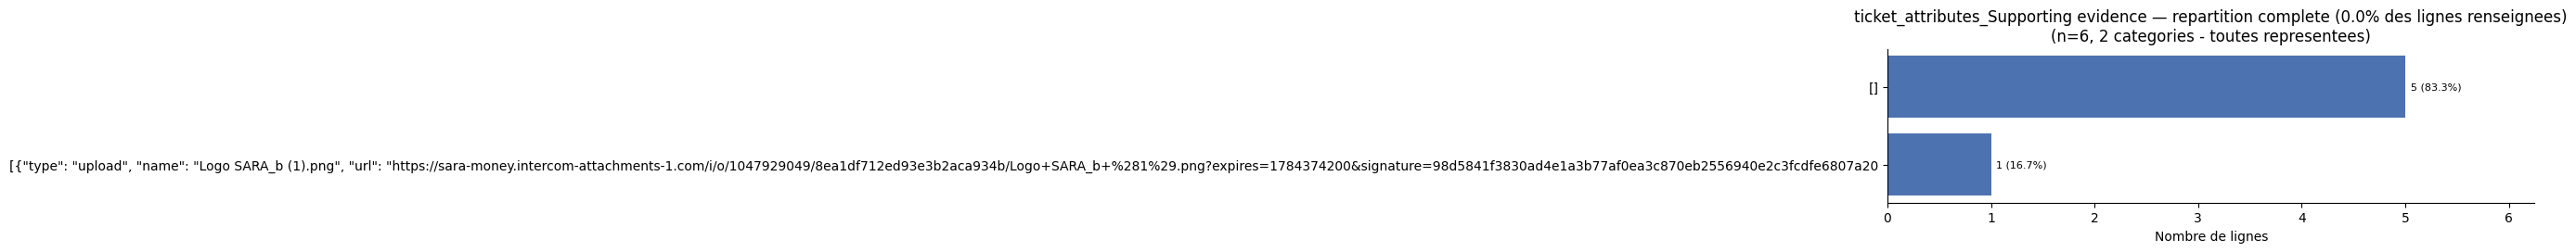

In [24]:
cols = ["ticket_attributes_Montant", "ticket_attributes_Numero errone", "ticket_attributes_Votre Numero", "ticket_attributes_Date de depot", "ticket_attributes_Agence concernee", "ticket_attributes_4 derniers chiffres de la carte", "ticket_attributes_Reference de la transaction1", "ticket_attributes_Date de depot du dossier", "ticket_attributes_Platforms", "ticket_attributes_Root cause", "ticket_attributes_Nom", "ticket_attributes_Numero de compte1", "ticket_attributes_Agence de domiciliation", "ticket_attributes_RIB de l'etranger", "ticket_attributes_Feature", "ticket_attributes_Priority", "ticket_attributes_Order number", "ticket_attributes_Amount", "ticket_attributes_Reason", "ticket_attributes_Supporting evidence"]
for c in cols:
    display_profile(df, c)


## 8. Colonnes derivees du text mining (Phases 1 a 4)

Les colonnes ci-dessous n'existent pas dans le CSV source : elles sont produites par le
pipeline (`phase1_cleaning.py` -> `phase4_reporting.py`, dont l'equivalent notebook se
trouve dans `02_sentiment.ipynb` et `03_topics.ipynb`). Meme regle appliquee : chacune
recoit un graphique, meme les colonnes PII quasi vides (ex. `pii_dates`).

--- texte ---
    dtype: object
    remplissage_pct: 100.0
    nb_remplis: 8284
    nb_valeurs_uniques: 8102
    valeur_plus_frequente: réclamation
    pct_valeur_plus_frequente: 0.23
    (pas de graphique - identifiant/texte libre/JSON/colonne constante : sans valeur analytique pour un graphique)
--- texte_masque ---
    dtype: object
    remplissage_pct: 100.0
    nb_remplis: 8284
    nb_valeurs_uniques: 8085
    valeur_plus_frequente: réclamation
    pct_valeur_plus_frequente: 0.23
    (pas de graphique - identifiant/texte libre/JSON/colonne constante : sans valeur analytique pour un graphique)
--- pii_telephones ---
    dtype: object
    remplissage_pct: 10.53
    nb_remplis: 872
    nb_valeurs_uniques: 774
    valeur_plus_frequente: 676110875;675110875
    pct_valeur_plus_frequente: 0.8
    (pas de graphique - identifiant/texte libre/JSON/colonne constante : sans valeur analytique pour un graphique)
--- pii_dates ---
    dtype: object
    remplissage_pct: 7.41
    nb_remplis: 614


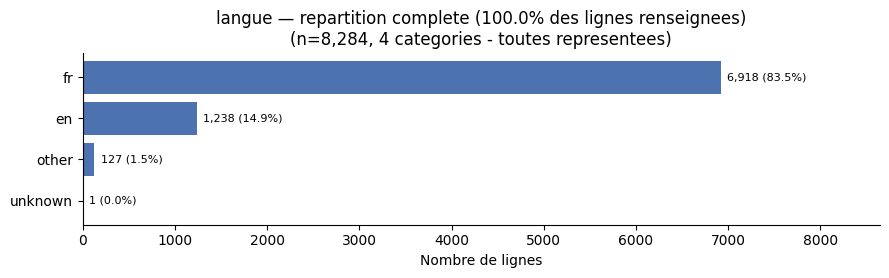

--- texte_lemmatise ---
    dtype: object
    remplissage_pct: 99.99
    nb_remplis: 8283
    nb_valeurs_uniques: 7975
    valeur_plus_frequente: réclamation
    pct_valeur_plus_frequente: 0.43
    (pas de graphique - identifiant/texte libre/JSON/colonne constante : sans valeur analytique pour un graphique)
--- sentiment_label ---
    dtype: object
    remplissage_pct: 100.0
    nb_remplis: 8284
    nb_valeurs_uniques: 3
    valeur_plus_frequente: negative
    pct_valeur_plus_frequente: 58.45


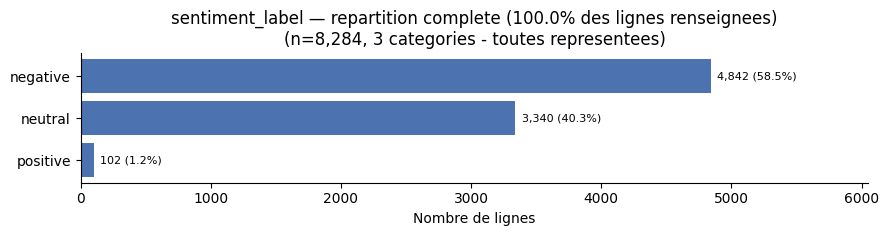

--- sentiment_score ---
    dtype: float64
    remplissage_pct: 100.0
    nb_remplis: 8284
    nb_valeurs_uniques: 3698
    moyenne: 0.81
    mediane: 0.85
    ecart_type: 0.15
    min: 0.3513
    q1: 0.7
    q3: 0.93
    max: 0.9899
    nb_outliers_iqr: 1
    pct_outliers: 0.01


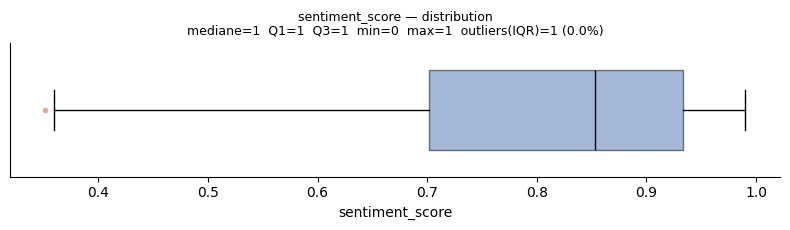

--- sentiment_scores_detail ---
    dtype: object
    remplissage_pct: 100.0
    nb_remplis: 8284
    nb_valeurs_uniques: 8064
    valeur_plus_frequente: neutral:0.5734;positive:0.248;negative:0.1786
    pct_valeur_plus_frequente: 0.23
    (pas de graphique - identifiant/texte libre/JSON/colonne constante : sans valeur analytique pour un graphique)
--- topic_id ---
    dtype: int64
    remplissage_pct: 100.0
    nb_remplis: 8284
    nb_valeurs_uniques: 9
    valeur_plus_frequente: 1
    pct_valeur_plus_frequente: 17.73


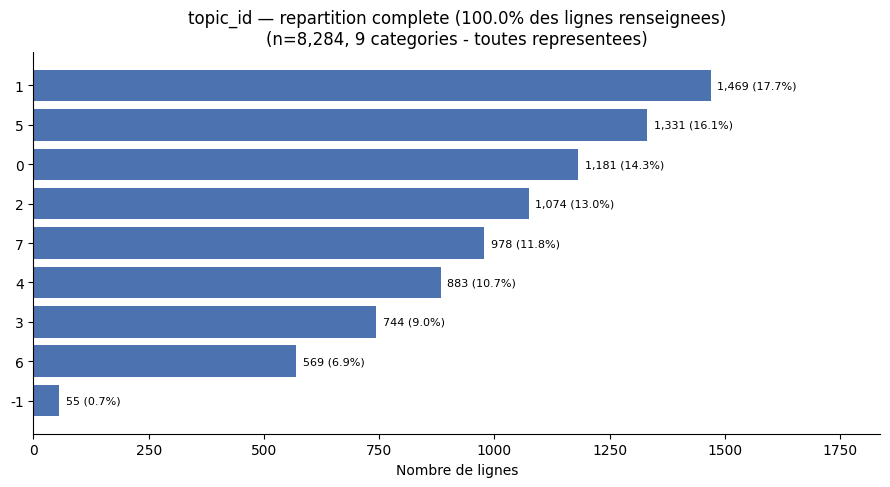

/home/gauss/Bureau/Afriland/sentiment analysis/notebooks/./viz_utils.py:95: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


--- topic_keywords ---
    dtype: object
    remplissage_pct: 99.34
    nb_remplis: 8229
    nb_valeurs_uniques: 34
    valeur_plus_frequente: money, orange money, orange, compte orange, compte, sara money, money compte, compte sara
    pct_valeur_plus_frequente: 9.95


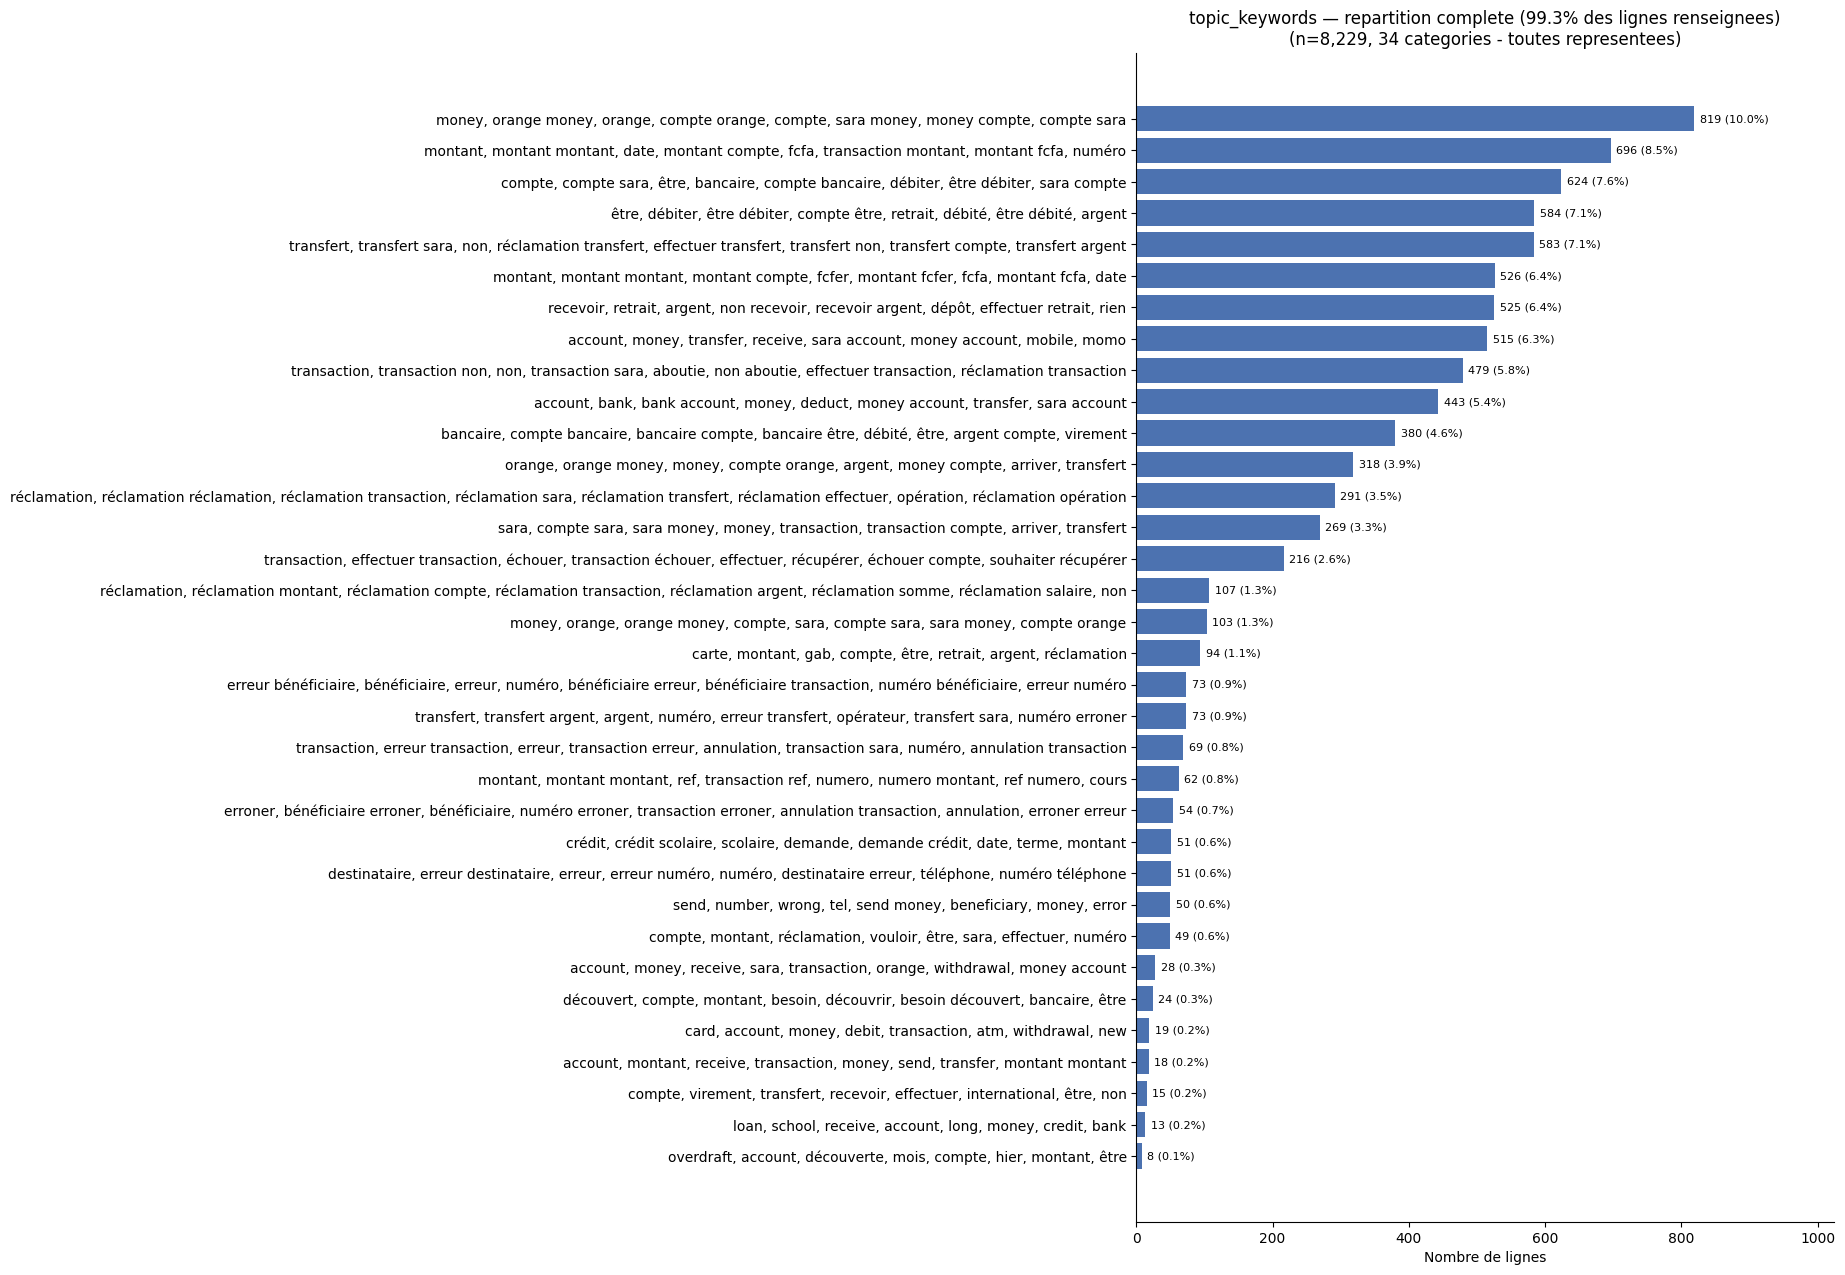

In [26]:
if PHASE3_CSV.exists():
    df_enrichi = pd.read_csv(PHASE3_CSV, low_memory=False)
    colonnes_derivees = [
        "texte", "texte_masque", "pii_telephones", "pii_dates", "pii_references",
        "pii_montants", "langue", "texte_lemmatise", "sentiment_label", "sentiment_score",
        "sentiment_scores_detail", "topic_id", "topic_keywords",
    ]
    for c in colonnes_derivees:
        display_profile(df_enrichi, c)
else:
    print(f"[!] {PHASE3_CSV.name} introuvable : lancer le pipeline (voir 01_nettoyage.ipynb a 04_reporting.ipynb) pour generer les colonnes derivees.")

## 9. Verification finale — aucune colonne oubliee

In [28]:
toutes_colonnes = set(df.columns)
colonnes_traitees = set()
for _, cols in [
    ("## 1. Identifiants & etat du ticket", ["type", "id", "ticket_id", "ticket_state_type", "ticket_state_id", "ticket_state_category", "ticket_state_internal_label", "ticket_state_external_label", "open", "category", "ticket_type_category"]),
    ("## 2. Classification — type de reclamation (`ticket_type_*`)", ["ticket_type_type", "ticket_type_id", "ticket_type_name", "ticket_type_description", "ticket_type_icon", "ticket_type_workspace_id", "ticket_type_archived", "ticket_type_created_at", "ticket_type_updated_at", "ticket_type_is_internal", "ticket_type_ticket_type_attributes_type", "ticket_type_ticket_type_attributes_data"]),
    ("## 3. Contact, canal, assignation", ["contacts_type", "contacts_contacts", "admin_assignee_id", "team_assignee_id", "channel", "is_shared"]),
    ("## 4. Horodatage", ["created_at", "updated_at"]),
    ("## 5. Parties du ticket / objets lies (metadonnees techniques Intercom)", ["ticket_parts_type", "ticket_parts_ticket_parts", "ticket_parts_total_count", "linked_objects_type", "linked_objects_data", "linked_objects_total_count", "linked_objects_has_more"]),
    ("## 6. Attributs metier frequents (29% a 46% de remplissage)", ["ticket_attributes__default_title_", "ticket_attributes__default_description_", "ticket_attributes_Nom du client", "ticket_attributes_Numero_tel_client", "ticket_attributes_Montant en XAF", "ticket_attributes_Reference de la transaction", "ticket_attributes_Agence", "ticket_attributes_Date de la transaction", "ticket_attributes_Numero de compte"]),
    ("## 7. Attributs metier rares — de 3,2% a 0,01% de remplissage", ["ticket_attributes_Montant", "ticket_attributes_Numero errone", "ticket_attributes_Votre Numero", "ticket_attributes_Date de depot", "ticket_attributes_Agence concernee", "ticket_attributes_4 derniers chiffres de la carte", "ticket_attributes_Reference de la transaction1", "ticket_attributes_Date de depot du dossier", "ticket_attributes_Platforms", "ticket_attributes_Root cause", "ticket_attributes_Nom", "ticket_attributes_Numero de compte1", "ticket_attributes_Agence de domiciliation", "ticket_attributes_RIB de l'etranger", "ticket_attributes_Feature", "ticket_attributes_Priority", "ticket_attributes_Order number", "ticket_attributes_Amount", "ticket_attributes_Reason", "ticket_attributes_Supporting evidence"])
]:
    colonnes_traitees |= set(cols)

manquantes = toutes_colonnes - colonnes_traitees
print(f"{len(colonnes_traitees)}/{len(toutes_colonnes)} colonnes du CSV source representees ci-dessus (graphique ou resume statistique).")
assert not manquantes, f"Colonnes non representees : {manquantes}"
print("OK : 100% des colonnes du dataset source ont ete representees (graphique quand pertinent, resume statistique sinon).")

67/67 colonnes du CSV source representees ci-dessus (graphique ou resume statistique).
OK : 100% des colonnes du dataset source ont ete representees (graphique quand pertinent, resume statistique sinon).
